In [13]:
# Get A Matrix from ODMR Data

This notebook takes ODMR data as input, fits it to extract the necessary parameters, and computes the linearized response matrix A and its pseudoinverse A+.

## Instructions for User:
1. Provide the path to your ODMR CSV file (e.g., 'ODMR_avg_99-6dBm_0mW.csv').
2. Manually identify and assign the four lower-frequency transitions to d1, d2, d3, d4 based on your experimental setup.
   - d1, d2 are typically below the plane, d3, d4 above.
   - Look at the fitted centers and assign them accordingly.
3. The notebook will output the A matrix and A+.

## 1. Imports and Constants


SyntaxError: invalid syntax (3249305164.py, line 3)

Loaded 1000 points
Frequency range [GHz]: 2.77 to 2.9698


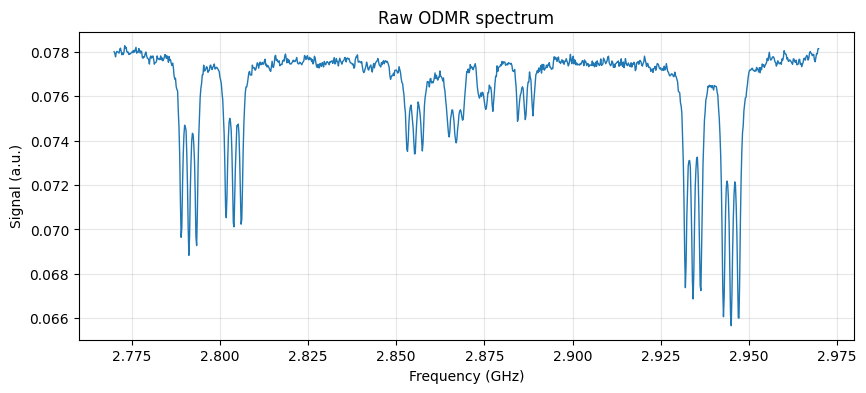

In [ ]:
# 2. Load ODMR Data
# Change this path to your ODMR CSV file
csv_path = "ODMR_avg_99-6dBm_0mW.csv"  # USER: Update this path

df = pd.read_csv(csv_path, sep=r"\s+")

# Make sure we work with NumPy arrays, not pandas Series
f_hz = df["Frequency"].to_numpy(dtype=float)
y_raw = df["Pixel(95-95)"].to_numpy(dtype=float)

# Sort by frequency just in case
idx = np.argsort(f_hz)
f_hz = f_hz[idx]
y_raw = y_raw[idx]

# Units
f_mhz = f_hz / 1e6
f_ghz = f_hz / 1e9

print("Loaded", len(f_hz), "points")
print("Frequency range [GHz]:", f_ghz.min(), "to", f_ghz.max())

plt.figure(figsize=(10, 4))
plt.plot(f_ghz, y_raw, lw=1)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Signal (a.u.)")
plt.title("Raw ODMR spectrum")
plt.grid(True, alpha=0.3)
plt.show()

Initial 8 center guesses [MHz]:
[2792.2 2805.  2854.2 2866.2 2874.6 2885.6 2935.2 2946. ]
len(p0) = 51
len(lb) = 51
len(ub) = 51
p0 inside bounds: True


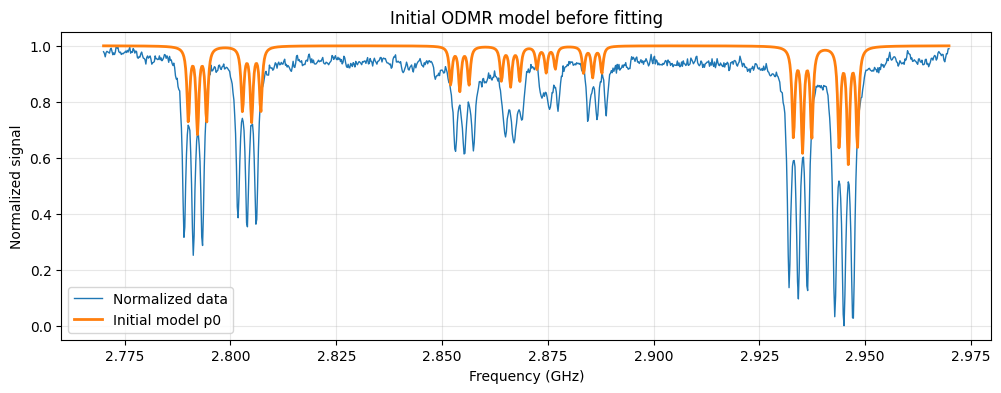

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7335e+01                                    4.03e+01    
       1              2         5.8463e+00      1.15e+01       1.71e+00       3.80e+00    
       2              3         2.4726e+00      3.37e+00       1.73e+00       2.44e+00    
       3              4         1.5913e+00      8.81e-01       1.77e+00       3.60e+00    
       4              5         1.3400e+00      2.51e-01       2.18e+00       3.90e+00    
       5              6         4.4573e-01      8.94e-01       5.47e-01       6.64e-01    
       6              7         1.7675e-01      2.69e-01       9.85e-01       1.28e+00    
       7              8         1.2925e-01      4.75e-02       1.22e+00       4.85e-01    
       8              9         1.0079e-01      2.85e-02       5.05e-01       8.28e-02    
       9             10         9.3851e-02      6.93e-03       5.03e-01       2.15e-01    

In [ ]:
# 3. Fit ODMR Data

# Initial guesses for the global fit
y_norm = normalize_signal(y_raw)

centers_guess, y_smooth, peak_idx, peak_prom = detect_8_transition_guesses(
    f_mhz, y_norm, smooth_window=21, polyorder=3, prominence=0.01
)
centers_guess = np.asarray(centers_guess, dtype=float)

print("Initial 8 center guesses [MHz]:")
print(np.round(centers_guess, 3))

# one hyperfine splitting guess per transition
delta_hf_guess = np.full(8, 2.16, dtype=float)

# one linewidth per transition
gamma_guesses = np.full(8, 0.8, dtype=float)

# three independent amplitudes per transition
amp_guesses = []
for c0 in centers_guess:
    mask = np.abs(f_mhz - c0) < 1.5
    local_depth = np.max(1.0 - y_norm[mask]) if np.any(mask) else 0.15

    # distribute initial amplitude roughly equally across the 3 hf lines
    a = max(local_depth, 0.05)
    amp_guesses.extend([0.35 * a, 0.40 * a, 0.35 * a])

amp_guesses = np.array(amp_guesses, dtype=float)

# baseline on centered x
b2_guess = 0.0
b1_guess = 0.0
b0_guess = 1.0

p0 = np.concatenate([
    centers_guess,      # 8
    delta_hf_guess,     # 8
    gamma_guesses,      # 8
    amp_guesses,        # 24
    [b2_guess, b1_guess, b0_guess]  # 3
])

# bounds
center_lb = centers_guess - 3.0
center_ub = centers_guess + 3.0

delta_lb = np.full(8, 1.7)
delta_ub = np.full(8, 2.5)

gamma_lb = np.full(8, 0.15)
gamma_ub = np.full(8, 2.5)

amp_lb = np.zeros(24)
amp_ub = np.full(24, 1.2)

lb = np.concatenate([
    center_lb,
    delta_lb,
    gamma_lb,
    amp_lb,
    [-1e-4, -1e-2, 0.7]
])

ub = np.concatenate([
    center_ub,
    delta_ub,
    gamma_ub,
    amp_ub,
    [1e-4, 1e-2, 1.2]
])

print("len(p0) =", len(p0))
print("len(lb) =", len(lb))
print("len(ub) =", len(ub))
print("p0 inside bounds:", np.all(p0 >= lb) and np.all(p0 <= ub))

# initial model check
y0 = odmr_model_full(f_mhz, p0)

plt.figure(figsize=(12, 4))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y0, label="Initial model p0", lw=2)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Initial ODMR model before fitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fit1 = least_squares(
    residuals_odmr_full,
    x0=p0,
    bounds=(lb, ub),
    args=(f_mhz, y_norm),
    method="trf",
    max_nfev=50000,
    verbose=2
)

p_fit = fit1.x
y_fit = odmr_model_full(f_mhz, p_fit)

centers_fit = np.asarray(p_fit[0:8], dtype=float)
delta_hf_fit = np.asarray(p_fit[8:16], dtype=float)
gamma_fit = np.asarray(p_fit[16:24], dtype=float)
amps_fit = np.asarray(p_fit[24:48], dtype=float).reshape(8, 3)

# sort by center for display / later pairing
order = np.argsort(centers_fit)
centers_fit = centers_fit[order]
delta_hf_fit = delta_hf_fit[order]
gamma_fit = gamma_fit[order]
amps_fit = amps_fit[order]

print("Fitted centers [MHz]:")
print(np.round(centers_fit, 4))
print("Fitted delta_hf_i [MHz]:")
print(np.round(delta_hf_fit, 4))
print("Fitted gamma_i [MHz]:")
print(np.round(gamma_fit, 4))
print("Fitted amplitudes per transition [A-, A0, A+]:")
print(np.round(amps_fit, 4))

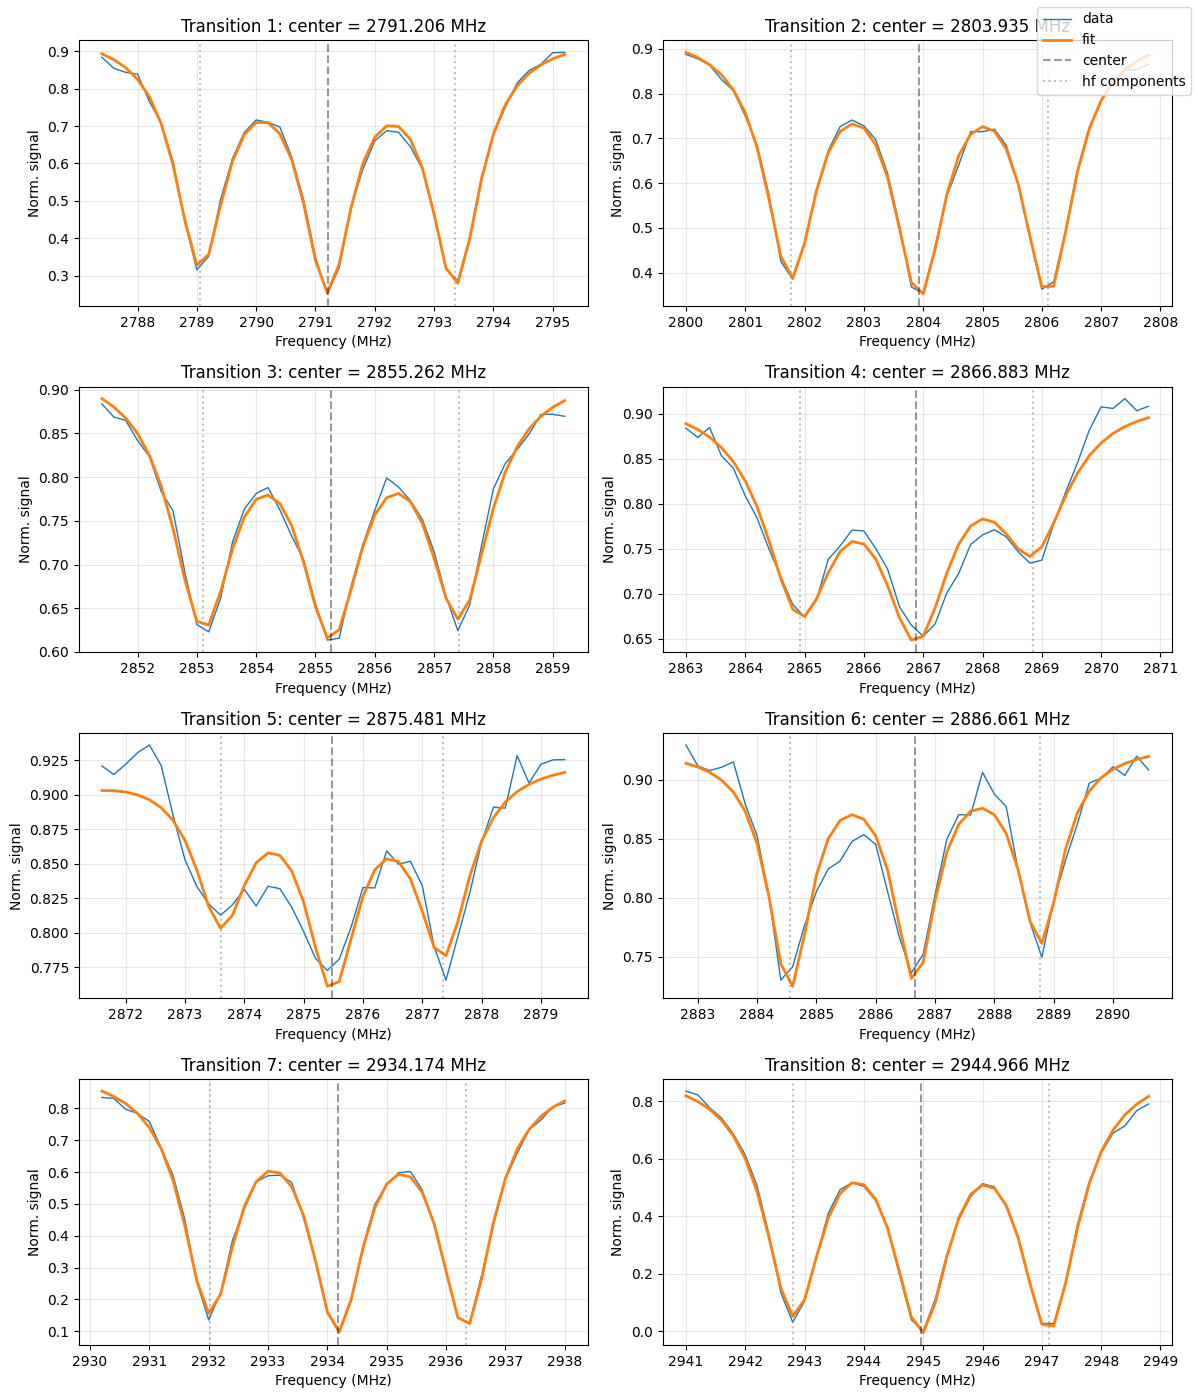

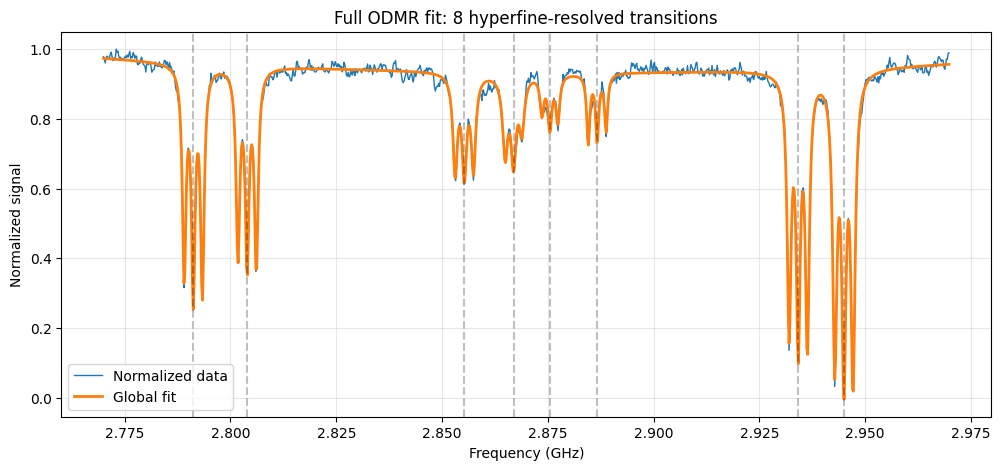

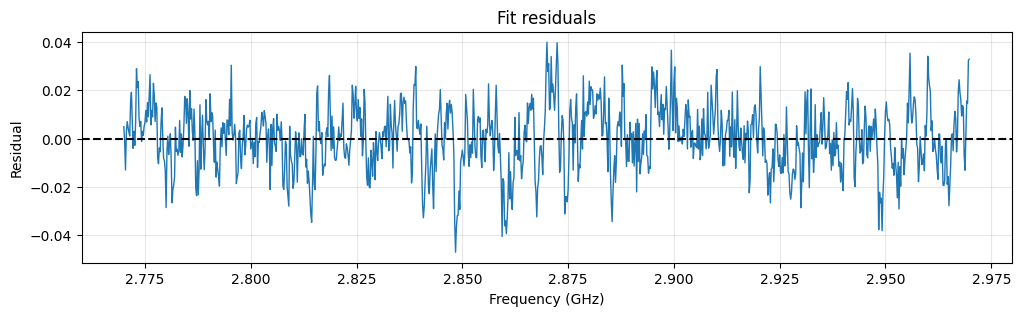

In [ ]:
# 4. Plot Fitted ODMR Data

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()

window_mhz = 4.0

# Use unsorted parameter blocks for component display if needed
centers_plot = centers_fit

for i, c in enumerate(centers_plot):
    ax = axes[i]
    mask = np.abs(f_mhz - c) < window_mhz

    ax.plot(f_mhz[mask], y_norm[mask], lw=1, label="data")
    ax.plot(f_mhz[mask], y_fit[mask], lw=2, label="fit")

    ax.axvline(c, color="k", ls="--", alpha=0.4, label="center" if i == 0 else None)
    ax.axvline(c - delta_hf_fit[i], color="gray", ls=":", alpha=0.5, label="hf components" if i == 0 else None)
    ax.axvline(c + delta_hf_fit[i], color="gray", ls=":", alpha=0.5)

    ax.set_title(f"Transition {i+1}: center = {c:.3f} MHz")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Norm. signal")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(f_ghz, y_norm, label="Normalized data", lw=1)
plt.plot(f_ghz, y_fit, label="Global fit", lw=2)

for c in centers_fit:
    plt.axvline(c / 1000.0, color="k", ls="--", alpha=0.25)

plt.xlabel("Frequency (GHz)")
plt.ylabel("Normalized signal")
plt.title("Full ODMR fit: 8 hyperfine-resolved transitions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(f_ghz, y_norm - y_fit, lw=1)
plt.axhline(0, color="k", ls="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Residual")
plt.title("Fit residuals")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 5. Manual Assignment of Transitions to NV Axes

# USER: Based on the fitted centers above and your experimental setup,
# assign the indices of the fitted centers to d1, d2, d3, d4.
# The centers_fit array is sorted by frequency (lowest to highest).
# Typically, the four lower-frequency transitions correspond to d1, d2, d3, d4 in some order.
# You need to identify which is which based on your setup.

# For example, if centers_fit[0] is d1, centers_fit[1] is d2, etc.
# Adjust these indices based on your knowledge.

d1_index = 0  # USER: Change this index for d1
d2_index = 1  # USER: Change this index for d2
d3_index = 2  # USER: Change this index for d3
d4_index = 3  # USER: Change this index for d4

# Extract the assigned centers
assigned_centers = {
    "d1": centers_fit[d1_index],
    "d2": centers_fit[d2_index],
    "d3": centers_fit[d3_index],
    "d4": centers_fit[d4_index],
}

print("Assigned centers [MHz]:")
for axis, center in assigned_centers.items():
    print(f"{axis}: {center:.4f}")

# For simplicity, assume the lower transitions are the ones we track
# In the original code, they paired left and right, but here we take the assigned as the tracked ones
f_left_meas = np.array([assigned_centers[ax] for ax in ["d1", "d2", "d3", "d4"]], dtype=float)

print("Tracked lower frequencies [MHz]:", f_left_meas)

Assigned centers [MHz]:
d1: 2791.2058
d2: 2803.9350
d3: 2855.2622
d4: 2866.8831
Tracked lower frequencies [MHz]: [2791.20577148 2803.93502334 2855.26217136 2866.88305566]


,axis,f_left_MHz,f_right_MHz,pair_center_MHz,splitting_MHz,abs_projection_axial_mT
0,d1,2791.205771,2944.966220,2868.085996,153.760448,2.743278
1,d2,2803.935023,2934.173508,2869.054265,130.238484,2.323617
2,d3,2855.262171,2886.660938,2870.961555,31.398766,0.560193
3,d4,2866.883056,2875.480576,2871.181816,8.597521,0.153390


Initial D guess [MHz] = 2869.820908
Initial Mz guesses [MHz]:
  d1: -1.734912
  d2: -0.766642
  d3:  1.140647
  d4:  1.360908
Best sign pattern: (-1.0, 1.0, 1.0, -1.0)
Initial B0 guess [mT] = (0.436979, 3.102826, 0.357869)
Initial SSR = 4.133534e-05


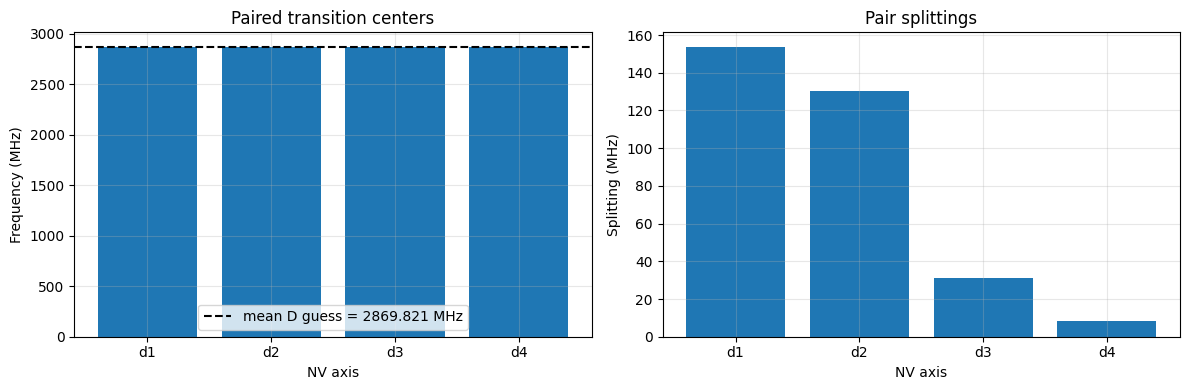

In [ ]:
# 6. Pair Transitions and Estimate Operating Point

# Assuming the assigned are the lower transitions in order d1, d2, d3, d4
# Pair with right transitions as d4, d3, d2, d1 (mirrored)

pairs = {
    "d1": (assigned_centers["d1"], centers_fit[7 - d1_index]),  # assuming sorted order
    "d2": (assigned_centers["d2"], centers_fit[7 - d2_index]),
    "d3": (assigned_centers["d3"], centers_fit[7 - d3_index]),
    "d4": (assigned_centers["d4"], centers_fit[7 - d4_index]),
}

# Note: This pairing assumes the standard order. If your assignment doesn't match, you may need to adjust.

summary_rows = []
for axis in ["d1", "d2", "d3", "d4"]:
    f_l, f_u = pairs[axis]
    center_pair = 0.5 * (f_l + f_u)
    splitting = f_u - f_l
    proj_abs_mt = splitting / (2.0 * GAMMA_E_MHZ_PER_MT)

    summary_rows.append({
        "axis": axis,
        "f_left_MHz": f_l,
        "f_right_MHz": f_u,
        "pair_center_MHz": center_pair,
        "splitting_MHz": splitting,
        "abs_projection_axial_mT": proj_abs_mt,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# Initial estimates for D and Mz from paired centers

D0_guess_mhz = summary_df["pair_center_MHz"].mean()

Mz0_guess = {
    row["axis"]: row["pair_center_MHz"] - D0_guess_mhz
    for _, row in summary_df.iterrows()
}

print(f"Initial D guess [MHz] = {D0_guess_mhz:.6f}")
print("Initial Mz guesses [MHz]:")
for axis in ["d1", "d2", "d3", "d4"]:
    print(f"  {axis}: {Mz0_guess[axis]: .6f}")

# Initial bias-field guess from axial Zeeman approximation

N_lab = np.vstack([NV_AXES["d1"], NV_AXES["d2"], NV_AXES["d3"], NV_AXES["d4"]])

proj_abs = summary_df["abs_projection_axial_mT"].to_numpy(dtype=float)

best = None
all_candidates = []

for signs in product([-1.0, 1.0], repeat=4):
    p_signed = np.array(signs, dtype=float) * proj_abs

    B_candidate, *_ = np.linalg.lstsq(N_lab, p_signed, rcond=None)
    residual = p_signed - N_lab @ B_candidate
    ssr = float(residual @ residual)

    all_candidates.append({
        "signs": signs,
        "Bx_mT": B_candidate[0],
        "By_mT": B_candidate[1],
        "Bz_mT": B_candidate[2],
        "SSR": ssr,
    })

    if best is None or ssr < best["SSR"]:
        best = {
            "signs": signs,
            "B": B_candidate,
            "SSR": ssr,
        }

best_signs = best["signs"]
B0_guess_mt = best["B"]
best_ssr = best["SSR"]

print("Best sign pattern:", best_signs)
print(f"Initial B0 guess [mT] = ({B0_guess_mt[0]:.6f}, {B0_guess_mt[1]:.6f}, {B0_guess_mt[2]:.6f})")
print(f"Initial SSR = {best_ssr:.6e}")

# Plot pair centers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(summary_df["axis"], summary_df["pair_center_MHz"])
axes[0].axhline(D0_guess_mhz, color="k", ls="--", label=f"mean D guess = {D0_guess_mhz:.3f} MHz")
axes[0].set_title("Paired transition centers")
axes[0].set_ylabel("Frequency (MHz)")
axes[0].set_xlabel("NV axis")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].bar(summary_df["axis"], summary_df["splitting_MHz"])
axes[1].set_title("Pair splittings")
axes[1].set_ylabel("Splitting (MHz)")
axes[1].set_xlabel("NV axis")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7. Hamiltonian Fit for Operating Point

def make_local_frame(n):
    """
    Construct a right-handed orthonormal local frame (ex, ey, ez),
    with ez parallel to the NV axis.
    """
    n = np.asarray(n, dtype=float)
    ez = n / np.linalg.norm(n)

    ref = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(ref, ez)) > 0.9:
        ref = np.array([1.0, 0.0, 0.0])

    ex = np.cross(ref, ez)
    ex = ex / np.linalg.norm(ex)

    ey = np.cross(ez, ex)
    ey = ey / np.linalg.norm(ey)

    return ex, ey, ez

# Local frames
LOCAL_FRAMES = {axis: make_local_frame(n) for axis, n in NV_AXES.items()}

def B_lab_to_local(B_lab_mt, axis_name):
    ex, ey, ez = LOCAL_FRAMES[axis_name]
    B_lab_mt = np.asarray(B_lab_mt, dtype=float)

    return np.array([
        np.dot(B_lab_mt, ex),
        np.dot(B_lab_mt, ey),
        np.dot(B_lab_mt, ez),
    ], dtype=float)

def hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    Bx_loc, By_loc, Bz_loc = B_lab_to_local(B_lab_mt, axis_name)
    zeeman = GAMMA_E_MHZ_PER_MT * (Bx_loc * Sx + By_loc * Sy + Bz_loc * Sz)
    return (D_mhz + Mz_mhz) * Sz2 + zeeman

def transition_frequencies_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    H = hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name)
    evals = np.linalg.eigvalsh(H)
    evals = np.sort(np.real(evals))

    f_lower = evals[1] - evals[0]
    f_upper = evals[2] - evals[0]
    return f_lower, f_upper

measured = pairs

def residuals_operating_point(theta):
    Bx, By, Bz, D_mhz, Mz_d1, Mz_d2, Mz_d3, Mz_d4 = theta
    B_lab = np.array([Bx, By, Bz], dtype=float)

    Mz_map = {
        "d1": Mz_d1,
        "d2": Mz_d2,
        "d3": Mz_d3,
        "d4": Mz_d4,
    }

    res = []
    for axis in ["d1", "d2", "d3", "d4"]:
        f_l_pred, f_u_pred = transition_frequencies_mhz(B_lab, D_mhz, Mz_map[axis], axis)
        f_l_meas, f_u_meas = measured[axis]

        res.append(f_l_pred - f_l_meas)
        res.append(f_u_pred - f_u_meas)

    return np.array(res, dtype=float)

theta0 = np.array([
    B0_guess_mt[0],
    B0_guess_mt[1],
    B0_guess_mt[2],
    D0_guess_mhz,
    Mz0_guess["d1"],
    Mz0_guess["d2"],
    Mz0_guess["d3"],
    Mz0_guess["d4"],
], dtype=float)

lb = np.array([
    -50.0, -50.0, -50.0,
    2800.0,
    -20.0, -20.0, -20.0, -20.0
])

ub = np.array([
     50.0,  50.0,  50.0,
    2940.0,
     20.0,  20.0,  20.0,  20.0
])

fit2 = least_squares(
    residuals_operating_point,
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=20000,
    verbose=2
)

theta_fit = fit2.x
Bx0, By0, Bz0, D_fit_mhz, Mz1_fit, Mz2_fit, Mz3_fit, Mz4_fit = theta_fit

Mz_fit_map = {
    "d1": Mz1_fit,
    "d2": Mz2_fit,
    "d3": Mz3_fit,
    "d4": Mz4_fit,
}
B_fit = np.array([Bx0, By0, Bz0], dtype=float)

print("\nRefined operating point:")
print(f"B0 [mT] = ({Bx0:.6f}, {By0:.6f}, {Bz0:.6f})")
print(f"|B0| [mT] = {np.linalg.norm(B_fit):.6f}")
print(f"D [MHz] = {D_fit_mhz:.6f}")
print("Mz [MHz]:")
for axis in ["d1", "d2", "d3", "d4"]:
    print(f"  {axis}: {Mz_fit_map[axis]: .6f}")

print(f"Residual norm [MHz] = {np.linalg.norm(fit2.fun):.6f}")

# Print relevant info
print("\nRelevant info for A:")
print(f"B0: {B_fit}")
print(f"D: {D_fit_mhz}")
print(f"Mz: {[Mz_fit_map[ax] for ax in ['d1','d2','d3','d4']]}")
print(f"Tracked frequencies: {f_left_meas}")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6653e+01                                    2.39e+03    
       1              2         1.4449e-01      3.65e+01       3.40e+00       5.09e+01    
       2              3         8.5236e-03      1.36e-01       3.79e-01       1.23e-01    
       3              4         8.5198e-03      3.76e-06       5.06e-02       4.54e-03    
       4             10         8.5198e-03      1.23e-11       2.45e-02       1.34e-03    
       5             11         8.5198e-03      5.65e-12       6.11e-03       1.42e-03    
       6             12         8.5198e-03      6.88e-13       1.53e-03       1.48e-03    
       7             15         8.5198e-03      0.00e+00       0.00e+00       1.48e-03    
`xtol` termination condition is satisfied.
Function evaluations 15, initial cost 3.6653e+01, final cost 8.5198e-03, first-order optimality 1.48e-03.

Refined operating point:
B0 [mT

Using central-difference step dB = 0.001 mT
A Matrix (MHz/mT):


,dnu_dBx,dnu_dBy,dnu_dBz
d1,0.356984,-22.163057,-17.190345
d2,0.355660,-21.881868,17.580840
d3,-22.812125,2.479327,-16.086076
d4,-21.442501,2.275476,15.650009


A Pseudoinverse (mT/MHz):


,dnu_d1,dnu_d2,dnu_d3,dnu_d4
Bx_recon,-0.001968,-0.002926,-0.022872,-0.022384
By_recon,-0.022954,-0.022530,-0.000408,-0.000322
Bz_recon,-0.015620,0.015784,-0.013867,0.014755


Condition number of A: 1.149035924447982


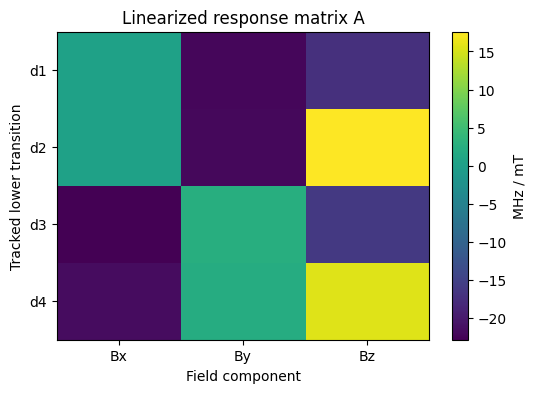

Round-trip reconstruction test:


,component,dB_true_mT,dB_recon_mT,error_uT
0,Bx,0.0020,0.0020,-1.301043e-15
1,By,-0.0010,-0.0010,1.084202e-15
2,Bz,0.0015,0.0015,-2.168404e-16


In [ ]:
# 8. Compute A Matrix and Pseudoinverse

# Central-difference field step for numerical linearization
dB_step_mT = 1e-3   # 1 microtesla

print("Using central-difference step dB =", dB_step_mT, "mT")

A = np.zeros((4, 3), dtype=float)

unit_vectors = np.eye(3)

axes_order = ["d1", "d2", "d3", "d4"]

for j in range(3):
    B_plus = B_fit + dB_step_mT * unit_vectors[j]
    B_minus = B_fit - dB_step_mT * unit_vectors[j]

    f_left_plus = []
    f_left_minus = []

    for axis in axes_order:
        ex = LOCAL_FRAMES[axis][0]
        ey = LOCAL_FRAMES[axis][1]
        ez = LOCAL_FRAMES[axis][2]

        # B_plus
        Bx_loc_p = np.dot(B_plus, ex)
        By_loc_p = np.dot(B_plus, ey)
        Bz_loc_p = np.dot(B_plus, ez)
        H_plus = (D_fit_mhz + Mz_fit_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_p * Sx + By_loc_p * Sy + Bz_loc_p * Sz)
        evals_plus = np.sort(np.real(np.linalg.eigvalsh(H_plus)))
        f_left_plus.append(evals_plus[1] - evals_plus[0])

        # B_minus
        Bx_loc_m = np.dot(B_minus, ex)
        By_loc_m = np.dot(B_minus, ey)
        Bz_loc_m = np.dot(B_minus, ez)
        H_minus = (D_fit_mhz + Mz_fit_map[axis]) * Sz2 + GAMMA_E_MHZ_PER_MT * (Bx_loc_m * Sx + By_loc_m * Sy + Bz_loc_m * Sz)
        evals_minus = np.sort(np.real(np.linalg.eigvalsh(H_minus)))
        f_left_minus.append(evals_minus[1] - evals_minus[0])

    f_left_plus = np.array(f_left_plus, dtype=float)
    f_left_minus = np.array(f_left_minus, dtype=float)

    A[:, j] = (f_left_plus - f_left_minus) / (2.0 * dB_step_mT)

A_df = pd.DataFrame(A, index=axes_order, columns=["dnu_dBx", "dnu_dBy", "dnu_dBz"])
print("A Matrix (MHz/mT):")
display(A_df)

A_plus = np.linalg.pinv(A)

A_plus_df = pd.DataFrame(
    A_plus,
    index=["Bx_recon", "By_recon", "Bz_recon"],
    columns=[f"dnu_{ax}" for ax in axes_order]
)

print("A Pseudoinverse (mT/MHz):")
display(A_plus_df)

# Condition number
U, svals, VT = np.linalg.svd(A, full_matrices=False)
cond_A = svals.max() / svals.min()
print(f"Condition number of A: {cond_A}")

# Plot A
plt.figure(figsize=(6, 4))
plt.imshow(A, aspect="auto")
plt.colorbar(label="MHz / mT")
plt.xticks([0, 1, 2], ["Bx", "By", "Bz"])
plt.yticks(range(4), axes_order)
plt.title("Linearized response matrix A")
plt.xlabel("Field component")
plt.ylabel("Tracked lower transition")
plt.show()

# Round-trip test
dB_test = np.array([0.002, -0.001, 0.0015], dtype=float)  # mT

dnu_test = A @ dB_test
dB_recon = A_plus @ dnu_test

roundtrip_df = pd.DataFrame({
    "component": ["Bx", "By", "Bz"],
    "dB_true_mT": dB_test,
    "dB_recon_mT": dB_recon,
    "error_uT": 1e3 * (dB_recon - dB_test),
})

print("Round-trip reconstruction test:")
display(roundtrip_df)

In [ ]:
# 7. Local Frames and Hamiltonian Functions

def make_local_frame(n):
    """
    Construct a right-handed orthonormal local frame (ex, ey, ez),
    with ez parallel to the NV axis.
    """
    n = np.asarray(n, dtype=float)
    ez = n / np.linalg.norm(n)

    ref = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(ref, ez)) > 0.9:
        ref = np.array([1.0, 0.0, 0.0])

    ex = np.cross(ref, ez)
    ex = ex / np.linalg.norm(ex)

    ey = np.cross(ez, ex)
    ey = ey / np.linalg.norm(ey)

    return ex, ey, ez

LOCAL_FRAMES = {axis: make_local_frame(n) for axis, n in NV_AXES.items()}

def B_lab_to_local(B_lab_mt, axis_name):
    ex, ey, ez = LOCAL_FRAMES[axis_name]
    B_lab_mt = np.asarray(B_lab_mt, dtype=float)

    return np.array([
        np.dot(B_lab_mt, ex),
        np.dot(B_lab_mt, ey),
        np.dot(B_lab_mt, ez),
    ], dtype=float)

def hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Reduced spin-1 Hamiltonian in MHz:
        H = (D + Mz) * Sz^2 + gamma_e * (Bx Sx + By Sy + Bz Sz)
    """
    Bx_loc, By_loc, Bz_loc = B_lab_to_local(B_lab_mt, axis_name)
    zeeman = GAMMA_E_MHZ_PER_MT * (Bx_loc * Sx + By_loc * Sy + Bz_loc * Sz)
    return (D_mhz + Mz_mhz) * Sz2 + zeeman

def transition_frequencies_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name):
    """
    Return lower and upper transition frequencies in MHz.
    """
    H = hamiltonian_mhz(B_lab_mt, D_mhz, Mz_mhz, axis_name)
    evals = np.linalg.eigvalsh(H)
    evals = np.sort(np.real(evals))

    f_lower = evals[1] - evals[0]
    f_upper = evals[2] - evals[0]
    return f_lower, f_upper

# Nonlinear fit of B0, D, and Mz

measured = pairs

def residuals_operating_point(theta):
    """
    theta = [Bx, By, Bz, D, Mz_d1, Mz_d2, Mz_d3, Mz_d4]

    Units:
    - B in mT
    - D, Mz in MHz
    """
    Bx, By, Bz, D_mhz, Mz_d1, Mz_d2, Mz_d3, Mz_d4 = theta
    B_lab = np.array([Bx, By, Bz], dtype=float)

    Mz_map = {
        "d1": Mz_d1,
        "d2": Mz_d2,
        "d3": Mz_d3,
        "d4": Mz_d4,
    }

    res = []
    for axis in ["d1", "d2", "d3", "d4"]:
        f_l_pred, f_u_pred = transition_frequencies_mhz(B_lab, D_mhz, Mz_map[axis], axis)
        f_l_meas, f_u_meas = measured[axis]

        res.append(f_l_pred - f_l_meas)
        res.append(f_u_pred - f_u_meas)

    return np.array(res, dtype=float)

theta0 = np.array([
    B0_guess_mt[0],
    B0_guess_mt[1],
    B0_guess_mt[2],
    D0_guess_mhz,
    Mz0_guess["d1"],
    Mz0_guess["d2"],
    Mz0_guess["d3"],
    Mz0_guess["d4"],
], dtype=float)

lb = np.array([
    -50.0, -50.0, -50.0,   # Bx, By, Bz [mT]
    2800.0,                # D [MHz]
    -20.0, -20.0, -20.0, -20.0
])

ub = np.array([
     50.0,  50.0,  50.0,
    2940.0,
     20.0,  20.0,  20.0,  20.0
])

fit2 = least_squares(
    residuals_operating_point,
    x0=theta0,
    bounds=(lb, ub),
    method="trf",
    max_nfev=20000,
    verbose=2
)

theta_fit = fit2.x
Bx0, By0, Bz0, D_fit_mhz, Mz1_fit, Mz2_fit, Mz3_fit, Mz4_fit = theta_fit

Mz_fit_map = {
    "d1": Mz1_fit,
    "d2": Mz2_fit,
    "d3": Mz3_fit,
    "d4": Mz4_fit,
}
B_fit = np.array([Bx0, By0, Bz0], dtype=float)

print("\nRefined operating point:")
print(f"B0 [mT] = ({Bx0:.6f}, {By0:.6f}, {Bz0:.6f})")
print(f"|B0| [mT] = {np.linalg.norm(B_fit):.6f}")
print(f"D [MHz] = {D_fit_mhz:.6f}")
print("Mz [MHz]:")
for axis in ["d1", "d2", "d3", "d4"]:
    print(f"  {axis}: {Mz_fit_map[axis]: .6f}")

print(f"Residual norm [MHz] = {np.linalg.norm(fit2.fun):.6f}")

# Print relevant info
print("\nRelevant info for A:")
print(f"B0: {B_fit}")
print(f"D: {D_fit_mhz}")
print(f"Mz: {[Mz_fit_map[ax] for ax in ['d1','d2','d3','d4']]}")
print(f"Tracked frequencies: {f_left_meas}")